# Capítulo 3 Uso y preparación de los datos

## 3.1 Lectura de datos##

### 3.1.2 Lectura de datos con Python###

In [255]:
import numpy
g = pandas.read_csv("train.txt",sep=",",header=0,decimal=".", index_col=0,dtype={"target":numpy.float64})
g.head()

,target,0,1,2,3,4,5,6,7,8,...,290,291,292,293,294,295,296,297,298,299
id,,,,,,,,,,,,,,,,,,,,,
0,1.0,-0.098,2.165,0.681,-0.614,1.309,-0.455,-0.236,0.276,-2.246,...,0.867,1.347,0.504,-0.649,0.672,-2.097,1.051,-0.414,1.038,-1.065
1,0.0,1.081,-0.973,-0.383,0.326,-0.428,0.317,1.172,0.352,0.004,...,-0.165,-1.695,-1.257,1.359,-0.808,-1.624,-0.458,-1.099,-0.936,0.973
2,1.0,-0.523,-0.089,-0.348,0.148,-0.022,0.404,-0.023,-0.172,0.137,...,0.013,0.263,-1.222,0.726,1.444,-1.165,-1.544,0.004,0.800,-1.211
3,1.0,0.067,-0.021,0.392,-1.637,-0.446,-0.725,-1.035,0.834,0.503,...,-0.404,0.640,-0.595,-0.966,0.900,0.467,-0.562,-0.254,-0.533,0.238
4,1.0,2.347,-0.831,0.511,-0.021,1.225,1.594,0.585,1.509,-0.012,...,0.898,0.134,2.415,-0.996,-1.006,1.378,1.246,1.478,0.428,0.253


## 3.2 Tratamiento previo de los datos##

### 3.2.1 Missing Values o valores faltantes

_Missing values en Python_

In [256]:
train=pandas.read_csv("train.txt",sep=",",header=0,decimal=".", index_col=0,dtype={"target":numpy.float64})

In [257]:
missing_values_count=train.isnull().sum()
missing_values_count

target    0
0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        0
24        0
25        0
26        0
27        0
28        0
         ..
270       0
271       0
272       0
273       0
274       0
275       0
276       0
277       0
278       0
279       0
280       0
281       0
282       0
283       0
284       0
285       0
286       0
287       0
288       0
289       0
290       0
291       0
292       0
293       0
294       0
295       0
296       0
297       0
298       0
299       0
Length: 301, dtype: int64

In [258]:
missing_values_count=train.isnull().sum()

In [259]:
total_cells=numpy.product(train.shape)
total_missing=missing_values_count.sum()
total_missing/total_cells*100

0.0

In [260]:
Columns_with_na_dropped=train.dropna(axis=1)

**Imputación de datos con Python: Sustitución por Media, Mediana y Moda**

**Sustitución por la media**

In [261]:
train.head()

,target,0,1,2,3,4,5,6,7,8,...,290,291,292,293,294,295,296,297,298,299
id,,,,,,,,,,,,,,,,,,,,,
0,1.0,-0.098,2.165,0.681,-0.614,1.309,-0.455,-0.236,0.276,-2.246,...,0.867,1.347,0.504,-0.649,0.672,-2.097,1.051,-0.414,1.038,-1.065
1,0.0,1.081,-0.973,-0.383,0.326,-0.428,0.317,1.172,0.352,0.004,...,-0.165,-1.695,-1.257,1.359,-0.808,-1.624,-0.458,-1.099,-0.936,0.973
2,1.0,-0.523,-0.089,-0.348,0.148,-0.022,0.404,-0.023,-0.172,0.137,...,0.013,0.263,-1.222,0.726,1.444,-1.165,-1.544,0.004,0.800,-1.211
3,1.0,0.067,-0.021,0.392,-1.637,-0.446,-0.725,-1.035,0.834,0.503,...,-0.404,0.640,-0.595,-0.966,0.900,0.467,-0.562,-0.254,-0.533,0.238
4,1.0,2.347,-0.831,0.511,-0.021,1.225,1.594,0.585,1.509,-0.012,...,0.898,0.134,2.415,-0.996,-1.006,1.378,1.246,1.478,0.428,0.253


In [262]:
promedio=train["0"].mean()
train["0"]=train["0"].replace(numpy.nan,promedio)

**Sustitución por la mediana**

In [263]:
mediana=train["0"].median()
train["0"]=train["0"].replace(numpy.nan,mediana)

**Sustitución por la moda**

In [264]:
moda=train["0"].mode()
train["0"]=train["0"].replace(numpy.nan,moda)

## 3.3 Identificación y tratamientos de Outliers o puntos atípicos

### 3.3.1 Identificación de puntos atípicos

### 3.3.3 Detección de outliers en Python

In [265]:
import pandas
data = pandas.read_csv("data.csv",index_col=0)

In [266]:
import matplotlib.pyplot as plt

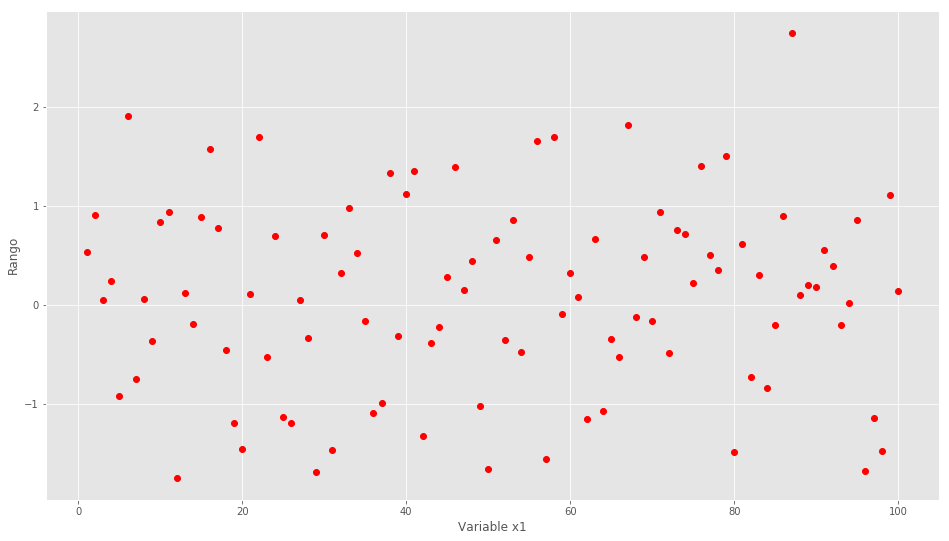

In [269]:
plt.plot(data.iloc[:,0],'ro')
plt.ylabel('Rango')
plt.xlabel('Variable x1')
plt.show()

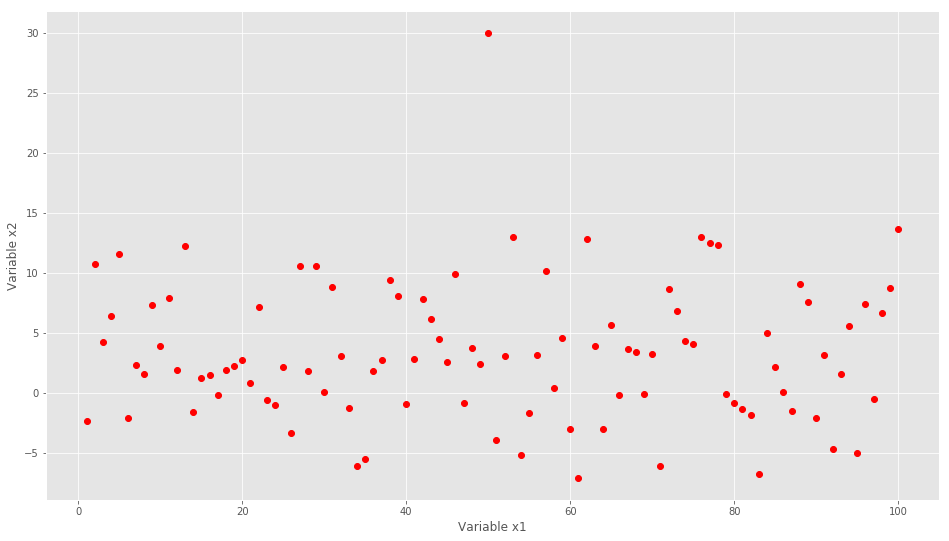

In [270]:
plt.plot(data.iloc[:,2],'ro')
plt.ylabel('Variable x2')
plt.xlabel('Variable x1')
plt.show()

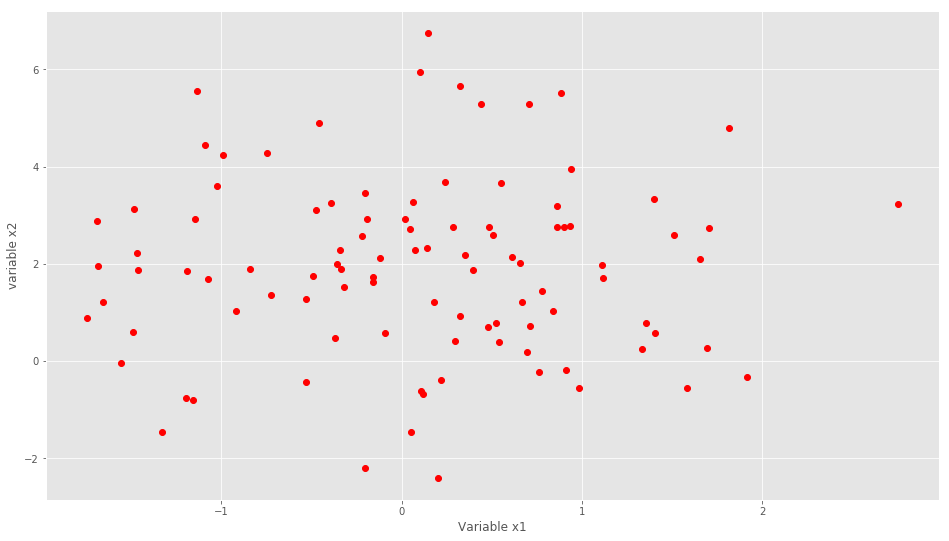

In [271]:
plt.plot(data.iloc[:,0],data.iloc[:,1],'ro')
plt.ylabel('variable x2')
plt.xlabel('Variable x1')
plt.savefig("Correlacion X1 con X3.png")
plt.show()

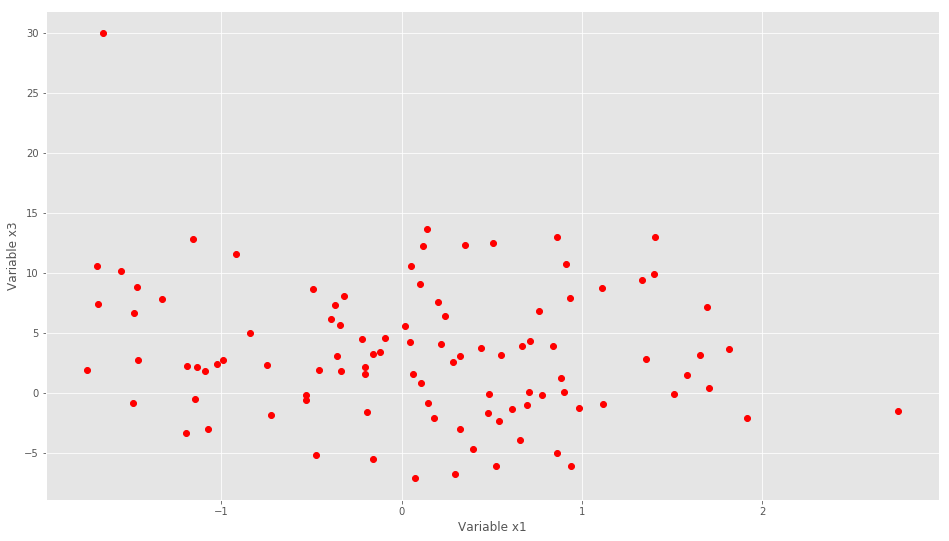

In [272]:
plt.plot(data.iloc[:,0],data.iloc[:,2],'ro')
plt.ylabel('Variable x3')
plt.xlabel('Variable x1')
plt.savefig("Out18.png")
plt.show()

* **La distancia Dm de Mahalanobis**

In [273]:
import scipy.spatial.distance as distance
import numpy

In [274]:
media = data.mean()

In [275]:
cov = numpy.cov(data.T)
Icov = numpy.linalg.inv(cov)

In [276]:
Mahalanobis = data.apply(distance.mahalanobis, axis=1,args=(media,Icov,))

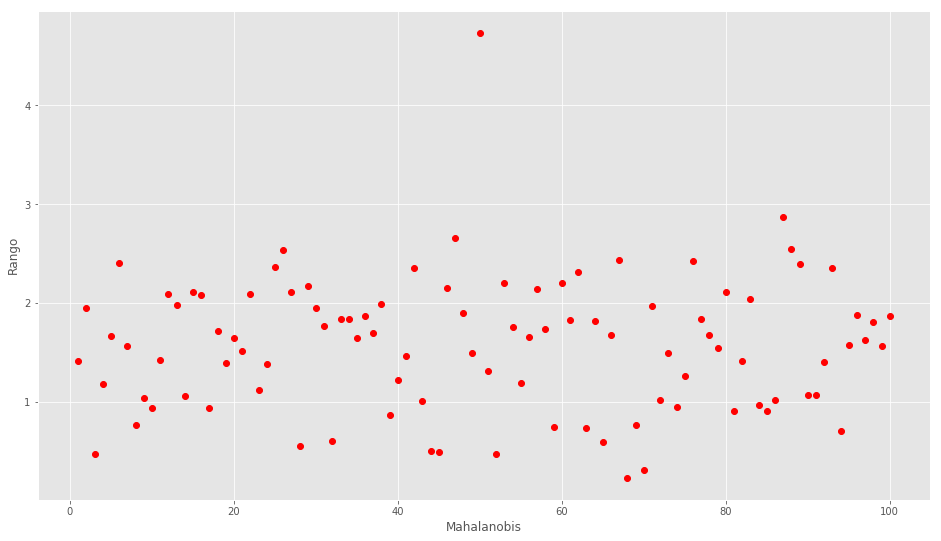

In [277]:
plt.plot(Mahalanobis,'ro')
plt.ylabel('Rango')
plt.xlabel('Mahalanobis')
plt.show()

# Capítulo 4 Regresión Lineal

## 4.1 Identificando relación entre variables

### 4.1.2 Identificando relación entre variables con Python

* **Visual**

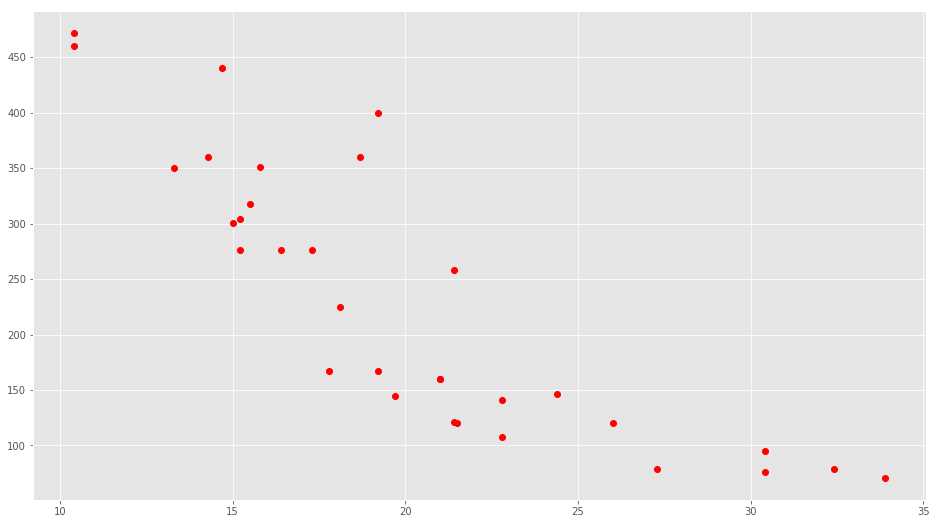

In [278]:
import pandas
df = pandas.read_csv("mtcars.csv")
plt.plot(df.iloc[:,1],df.iloc[:,3],"ro")

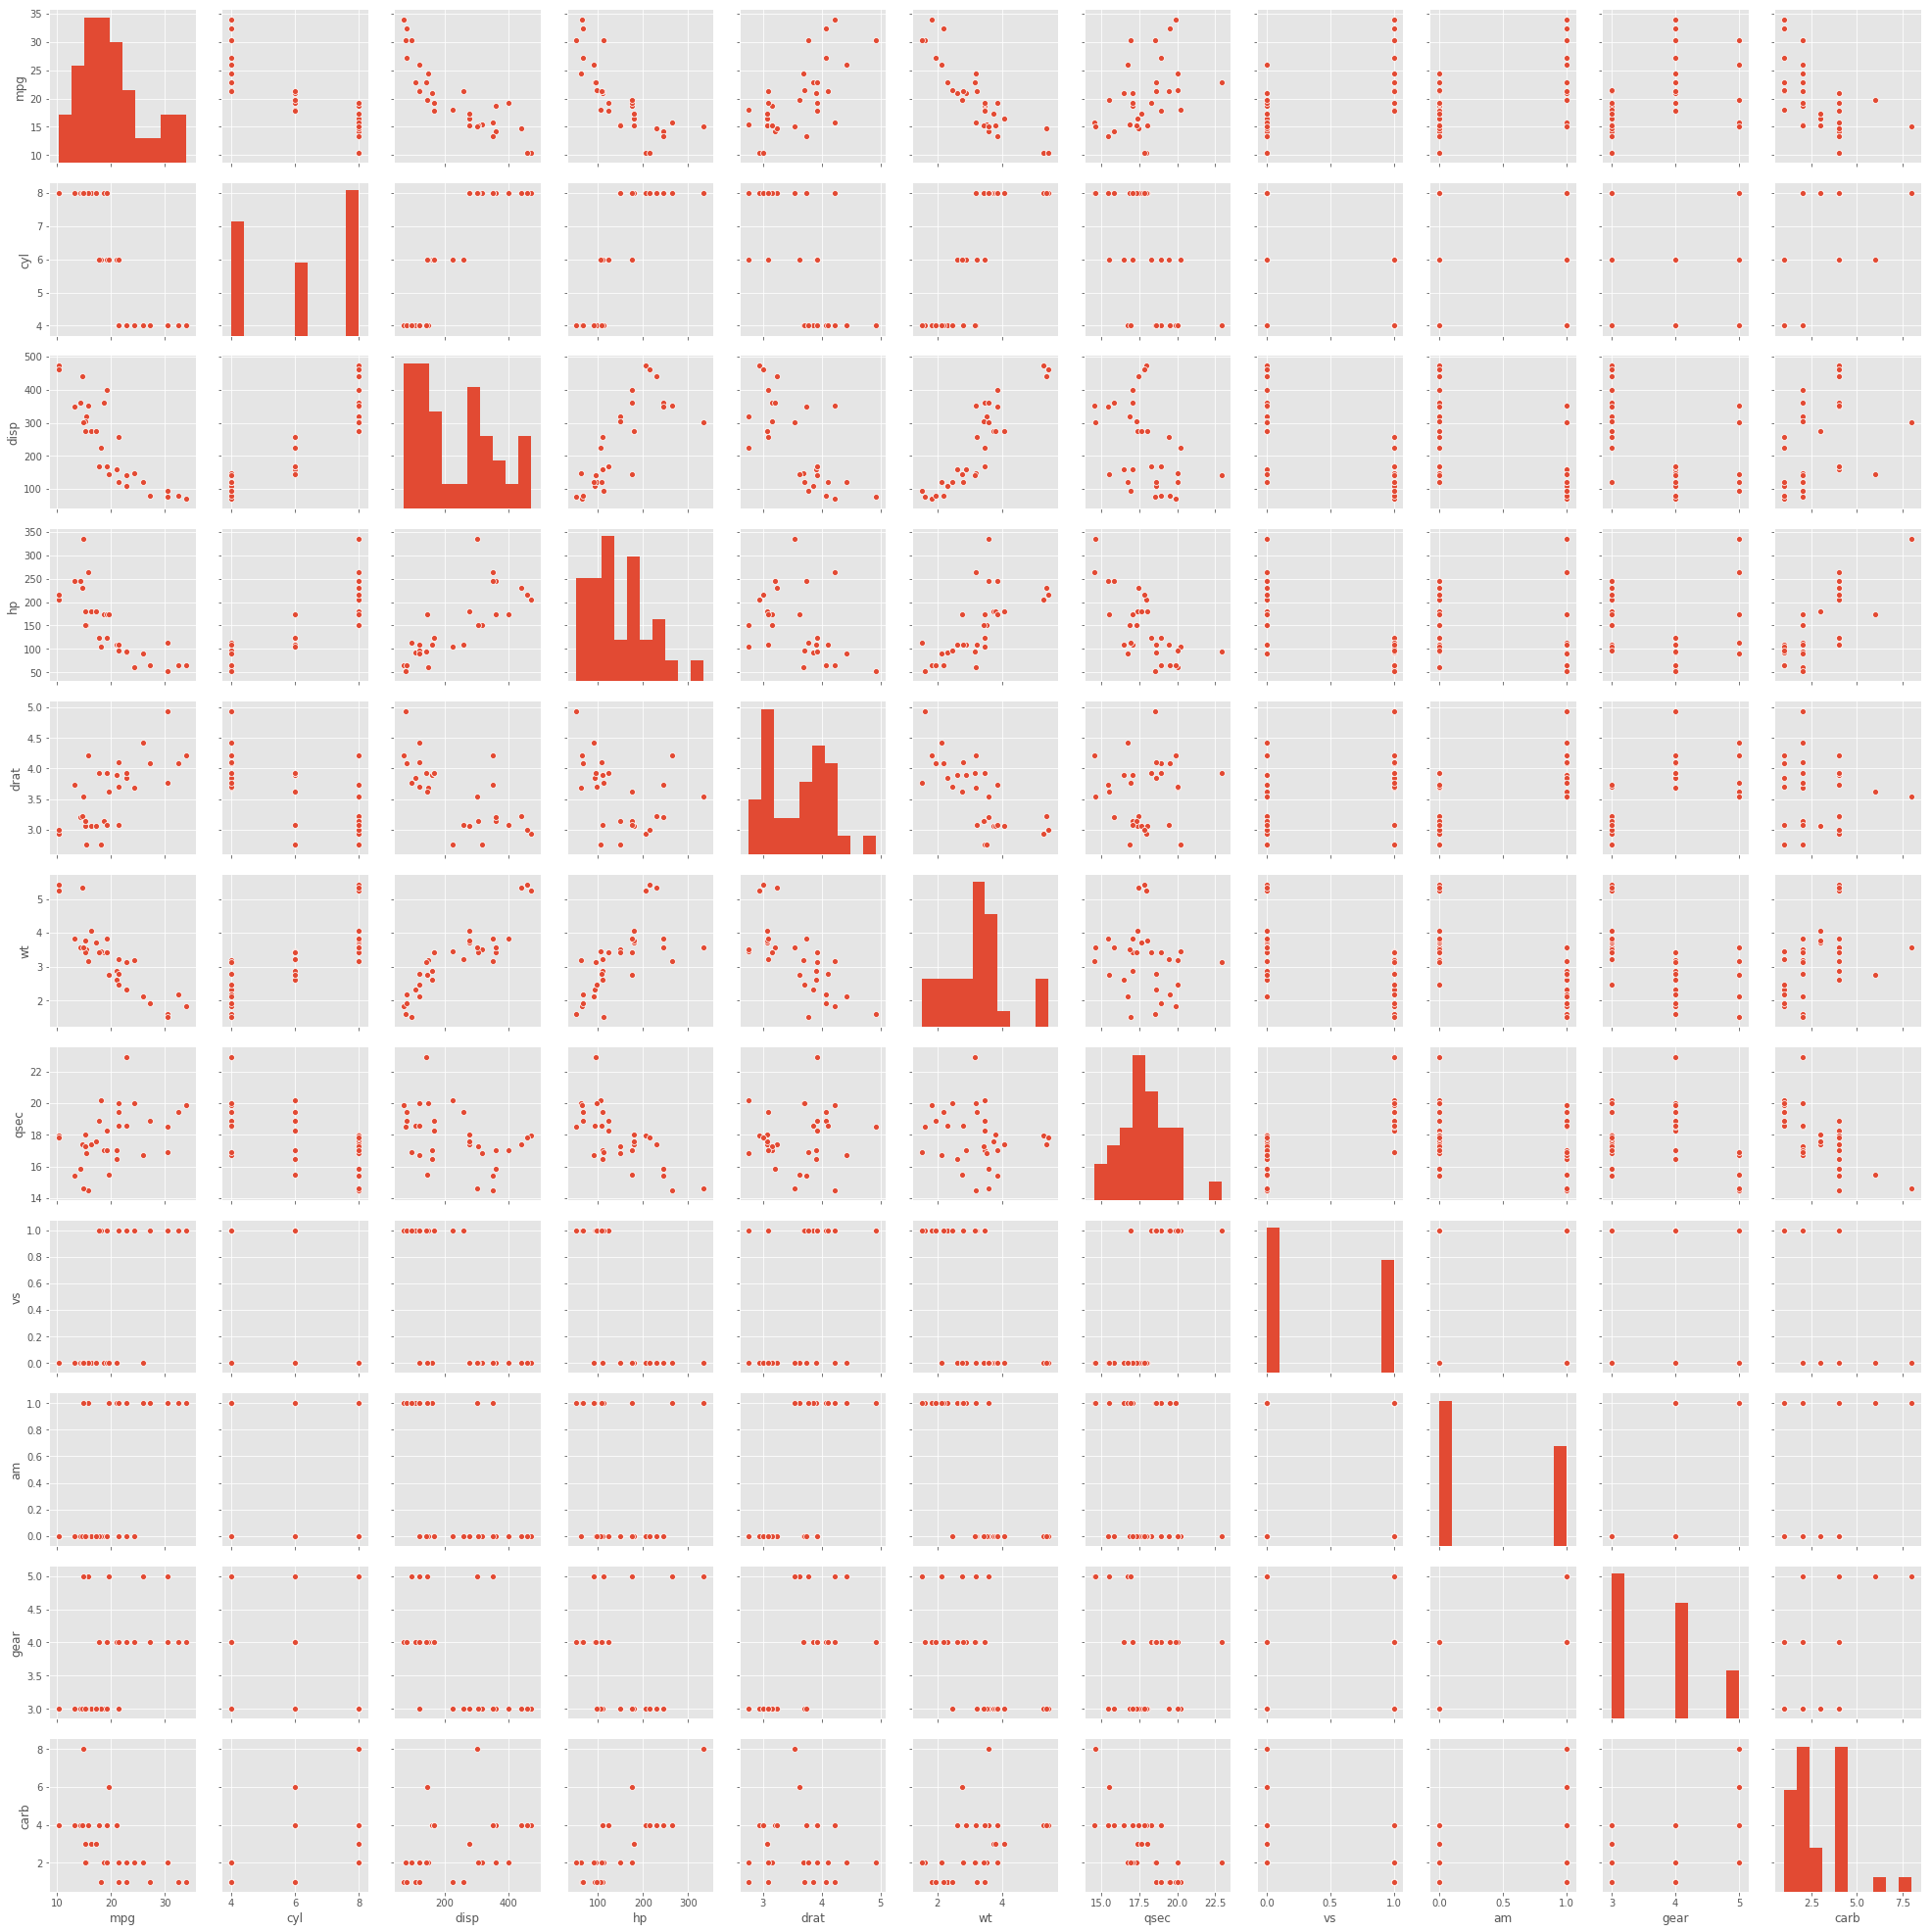

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df, kind="scatter",  palette="Set2")
plt.show()

* **Cuantitativo**

Para obtener la matriz de correlación entre las variables usamos la función ".cor()" de la librería Pandas. En el caso que queramos alguna correlación en específico filtramos los elementos de la matriz obtenida:

In [280]:
corre=df.corr()
corre

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


## 4.2 Transformando variables

### 4.2.2 Aplicando transformaciones de variables en Python

Utilizamos la base de datos mtcars y renombramos la variable "disp" por "x", luego hacemos las transformaciones

In [281]:
df = pandas.read_csv("mtcars.csv")
df.rename(columns={'mpg': 'x'}, inplace=True)

In [282]:
### funcion X^2

df[["x"]] = df[["x"]]**2
df.head()

,Unnamed: 0,x,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,441.00,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,441.00,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,519.84,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,457.96,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,349.69,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [283]:
### Función raíz de X

df[["x"]] = df[["x"]]**(1/2)


### Función 1/X

df[["x"]] = 1/df[["x"]]


### Función log(x)

import math

df[["x"]] = df[["x"]].apply(math.log, axis=1)

## 4.4 Eliminación de las variables categóricas

### 4.4.2 Eliminación de variables en Python

In [284]:
mtcars = pandas.read_csv("mtcars.csv")
mtcars = mtcars.drop("mpg", axis=1)
mtcars.head()

,Unnamed: 0,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## 4.5 Aplicando el modelo de regresión lineal

### 4.5.2 Aplicando el modelo de regresión lineal en Python

In [285]:
irisp = pandas.read_csv("irisp.csv",sep=";")

In [286]:
import statsmodels.api as sm

In [287]:
var_dep = irisp["Sepal.Length"]

var_ind = irisp.drop("Sepal.Length",axis=1)

In [288]:
var_ind1 = sm.add_constant(var_ind)

C:\Users\Bernardo\Anaconda2\lib\site-packages\numpy\core\fromnumeric.py:2389: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


In [289]:
model = sm.OLS(var_dep, var_ind1).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Sepal.Length   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     295.5
Date:                Thu, 20 Jun 2019   Prob (F-statistic):           8.59e-62
Time:                        15:16:42   Log-Likelihood:                -37.321
No. Observations:                 150   AIC:                             82.64
Df Residuals:                     146   BIC:                             94.69
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8560      0.251      7.401   

## 4.6 Cómo interpretar los resultados del modelo

### 4.6.2 Interpretar con summary en Python

(array([ 2.,  6., 17., 27., 21., 36., 21., 13.,  5.,  2.]),
 array([-0.82816369, -0.6607777 , -0.49339171, -0.32600572, -0.15861973,
         0.00876626,  0.17615224,  0.34353823,  0.51092422,  0.67831021,
         0.8456962 ]),
 <a list of 10 Patch objects>)

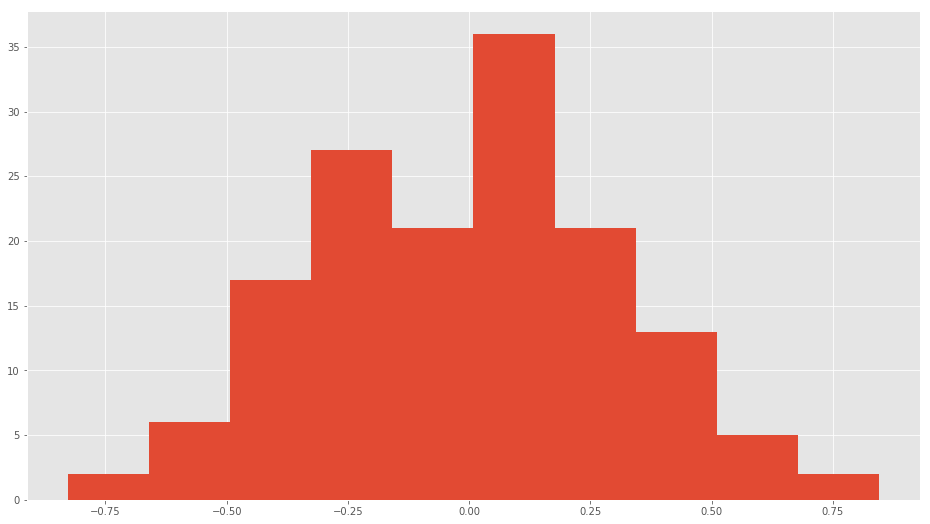

In [290]:
plt.hist(model.resid)

## 4.7 Realizando predicciones con nuestro modelo

### 4.7.2 Realizando predicciones con Python

In [291]:
pre = irisp.drop("Sepal.Length",axis=1)

In [292]:
pre = sm.add_constant(pre)

**Predicciones**

In [293]:
predicciones = model.predict(pre)

# Capítulo 5 Regresión logística

## 5.3 Detectar correlación entre variables categóricas

### 5.3.2 Prueba chi-cuadrado en Python

**Cargamos la librería**

In [294]:
import scipy.stats as stats

**Realizamos e imprimimos el valor del $p$-valor**

In [295]:
d = pandas.read_csv("prueba.txt",index_col=0)

chi2, p, dof, expected = stats.chi2_contingency(d) 

print(p)

0.2283643947212718


## 5.4 Detectar correlación entre variables categóricas y variables cuantitativas

### 5.4.2 Medida de $d$ de Cohen en Python

In [296]:
from statistics import mean, stdev
from math import sqrt
c0=[2,4,7,3,7,35,8,9]
c1=[4,8,14,6,14,70,16,18]
cohen_d=(mean(c0)-mean(c1))/(sqrt((stdev(c0)**2+stdev(c1)**2)/2))
print(cohen_d)

-0.5567679522645598


## 5.5 Codificando variables categóricas

### 5.5.2 Creación de variables auxiliares en Python

In [297]:
import pandas
color=["azul", "rojo", "amarillo","blanco","amarillo","azul","azul","rojo"]
dummies=pandas.get_dummies(color)
dummies = dummies.drop(dummies.columns[[0]],axis=1)
dummies

,azul,blanco,rojo
0,1,0,0
1,0,0,1
2,0,0,0
3,0,1,0
4,0,0,0
5,1,0,0
6,1,0,0
7,0,0,1


## 5.6 Aplicando el modelo de regresión logística

## 5.6.2 Modelo logístico en Python

**Cargamos las librerías y los datos**

In [298]:
import pandas as pd
import statsmodels.api as sm

data = pd.read_csv("logistica.csv")
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


**Seleccionamos las variables independientes y dependiente**

In [299]:
Y = data[["default"]]
X = data[["student","balance"]]

**Modificamos las variables categóricas**

In [300]:
X = X.replace("No", 0).replace("Yes",1)
X = sm.add_constant(X)
Y = Y.replace("No", 0).replace("Yes",1)

**Creamos y ajustamos el modelo**

In [301]:
model = sm.Logit(Y, X)
 
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.078584
         Iterations 10


**Resumen del modelo**

In [302]:
 result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Thu, 20 Jun 2019   Pseudo R-squ.:                  0.4619
Time:                        15:17:45   Log-Likelihood:                -785.84
converged:                       True   LL-Null:                       -1460.3
                                        LLR p-value:                1.189e-293
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.7495      0.369    -29.115      0.000     -11.473     -10.026
student       -0.7149      0.148     -4.846      0.000      -1.004      -0.426
balance        0.0057      0.000     24.748      0.000       0.005       0.006
==============================================================================

Possibly complete quasi-separation: A fraction 0.15 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

**Realizando predicciones**

In [303]:
result.predict(X.iloc[[9998]])

9998    0.148507
dtype: float64

# Capítulo 6 Análisis de clúster

## 6.6 Análisis de clúster en Python

### 6.6.1 Método no jerárquico

**Librerías a usar**

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

**Conjunto de datos**

In [305]:
datos = pd.read_csv("datos_cluster.csv",index_col=0)

**Costrucción del gráfico de codo**

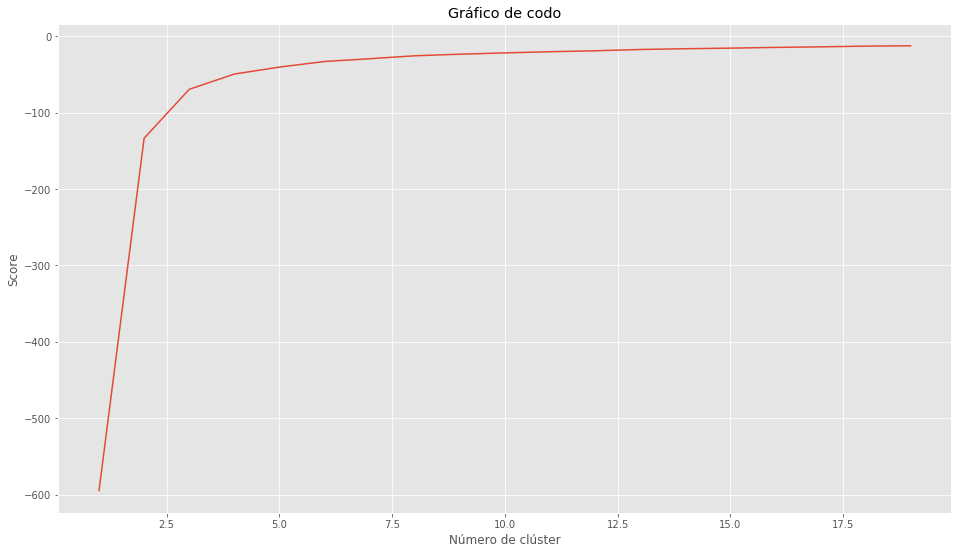

In [306]:
Nc = range(1, 20)
kmeans = [KMeans(n_clusters=i) for i in Nc]
kmeans
score = [kmeans[i].fit(datos).score(datos) for i in range(len(kmeans))]
score
plt.plot(Nc,score)
plt.xlabel('Número de clúster')
plt.ylabel('Score')
plt.title('Gráfico de codo')
plt.savefig("GraficoCodo.png")
plt.show()

**Construyendo los grupos**

In [307]:
kmeans = KMeans(n_clusters=3).fit(datos)

**Grupos**

In [308]:
labels = kmeans.predict(datos)

### 6.6.2 Método jerárquico

**Clústeres jerárquicos**

In [309]:
cluster = pd.read_csv("datos_cluster.csv",index_col=0)

**Construyendo el dendrograma**

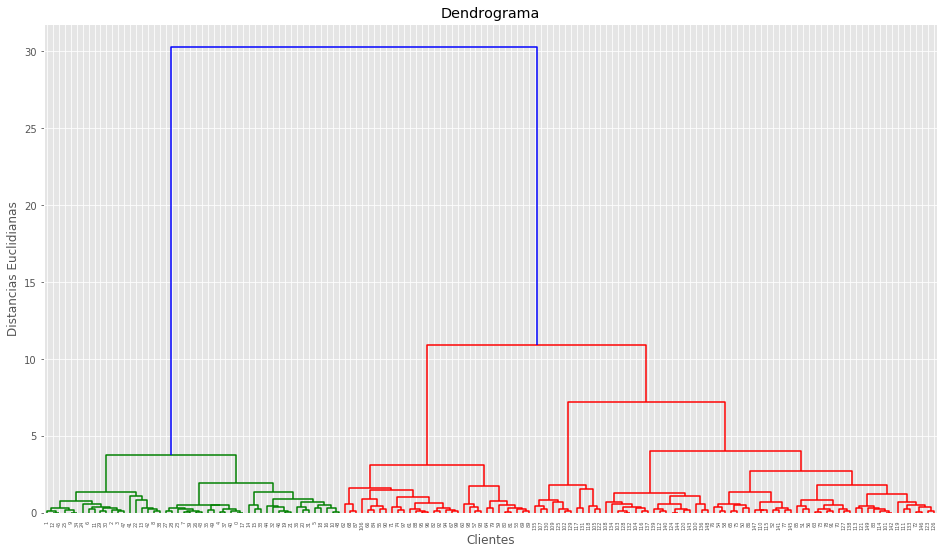

In [310]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(cluster, method = 'ward'))

plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancias Euclidianas')
plt.savefig("Dendrograma.png")
plt.show()

**Obtener los clústeres de los datos**

In [311]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters = 3, 
                    affinity = 'euclidean', 
                    linkage = 'ward')

y_hc = hc.fit_predict(cluster)

y_hc

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

# Capítulo 7 Análisis de Componentes Principales

## 7.4 PCA en Python

### 7.4.1 Librerías y datos

**PCA**

**Paquetes y datos**

In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["figure.figsize"]=(16,9)
plt.style.use("ggplot")

In [313]:
datos=pd.read_csv("pca.csv",index_col=0)

### 7.4.2 Cálculo de componentes

**Media y Varianza**

In [314]:
datos.mean()

Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

In [315]:
datos.var()

Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

**Normalizando los datos**

In [332]:
d = iris[["Sepal.Length","Sepal.Width","Petal.Length","Petal.Width"]]
from sklearn.preprocessing import scale
data=pd.DataFrame(scale(d))

**Calculando componentes**

In [333]:
from sklearn.decomposition import PCA
pca=PCA().fit(d)
pca_samples=pca.transform(d)

### 7.4.3 Funciones Gráficas

**Función para graficar componentes**

In [334]:
def pca_results(good_data, pca):
    '''
    Create a DataFrame of the PCA results
    Includes dimension feature weights and explained variance
    Visualizes the PCA results
    '''

    #Indexando las dimensiones
    dimensions = dimensions = ['Dimension {}'.format(i) for i in range(1,len(pca.components_)+1)]

    # Componentes PCA
    components = pd.DataFrame(np.round(pca.components_, 4), columns = list(good_data.keys()))
    components.index = dimensions

    # varianza explicada PCA
    ratios = pca.explained_variance_ratio_.reshape(len(pca.components_), 1)
    variance_ratios = pd.DataFrame(np.round(ratios, 4), columns = ['Explained Variance'])
    variance_ratios.index = dimensions

    # Crear una visualización en gráfico de barra 
    fig, ax = plt.subplots(figsize = (14,8))

    # graficar la característica Pesos como una función de las componentes
    components.plot(ax = ax, kind = 'bar');
    ax.set_ylabel("Feature Weights")
    ax.set_xticklabels(dimensions, rotation=0)


    # Mostrar los ratios de la varianza explicada 
    for i, ev in enumerate(pca.explained_variance_ratio_):
        ax.text(i-0.40, ax.get_ylim()[1] + 0.05, "Explained Variance\n%.4f"%(ev))

    # Obtener un DataFrame concatenado
    return pd.concat([variance_ratios, components], axis = 1)

**Gráfico de codo**

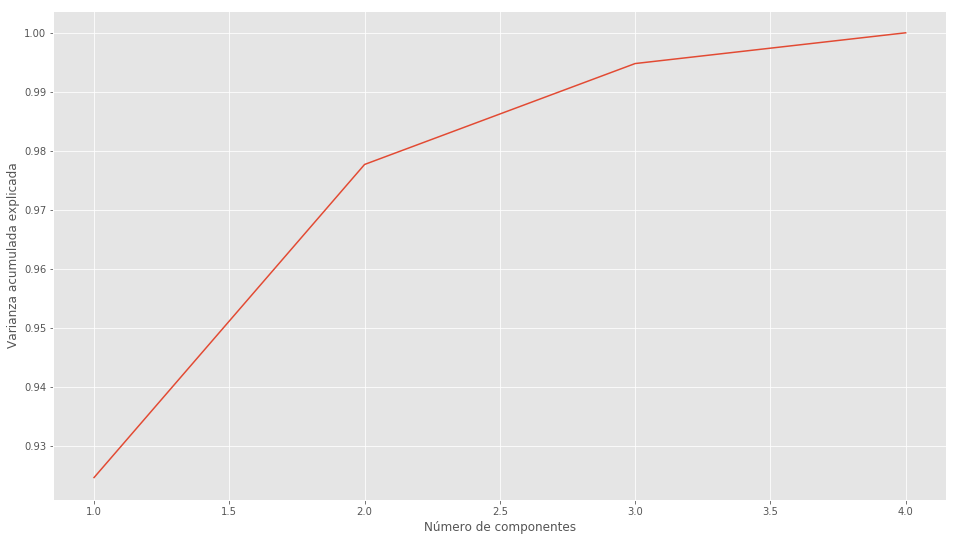

In [335]:
plt.plot(list(range(1,len(pca.explained_variance_ratio_)+1)), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada explicada")
plt.show()

# Capítulo 8 Árboles de decisión y bosques aleatorios

## 8.1 Árboles de decisión

### 8.1.2 Árboles de decisión en Python

**Librerías y datos**

In [337]:
from sklearn.tree import DecisionTreeClassifier

In [338]:
iris = pd.read_csv("arbol.csv",index_col=0)

predictores = iris[["Sepal.Length", "Sepal.Width","Petal.Width"]]
objetivo = iris[["Species"]]

**Construcción del modelo**

In [339]:
Arbol =DecisionTreeClassifier()
Arbol = Arbol.fit(predictores,objetivo)

**Predicciones**

In [340]:
predicciones = Arbol.predict(predictores)

# 8.2 Bosques aleatorios

## 8.4 Bosques aleatorios en Python

In [341]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
iris = load_iris()

In [342]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Variables independientes**

In [343]:
predictores=df.columns[:4]

**Agregando variable a predecir**

In [344]:
df["species"]=pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [345]:
objetivo=pd.factorize(df["species"])[0]
objetivo

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int64)

**Creando el modelo**

In [346]:
clf = RandomForestClassifier(n_jobs=2,random_state=0)
clf.fit(df[predictores],objetivo)

C:\Users\Bernardo\Anaconda2\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=2,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

**Predicciones**

In [143]:
clf.predict(df[predictores])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int64)